In [47]:
import sys 
sys.path.append(os.path.abspath('..'))

In [48]:
import tensorflow as tf
from src.dataset import get_dataset

In [49]:
model = tf.keras.models.load_model(
    "../models/digit_classifier5.keras"
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,264,928 (4.83 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 843,286 (3.22 MB)

In [50]:
original_train, original_val = get_dataset(
    "../data/dataset_farsi"
)

synthetic_train, synthetic_val = get_dataset(
    "../data/synthetic_dataset"
)

Found 80000 files belonging to 10 classes.
Using 56000 files for training.
Found 80000 files belonging to 10 classes.
Using 24000 files for validation.
Found 40000 files belonging to 10 classes.
Using 28000 files for training.
Found 40000 files belonging to 10 classes.
Using 12000 files for validation.


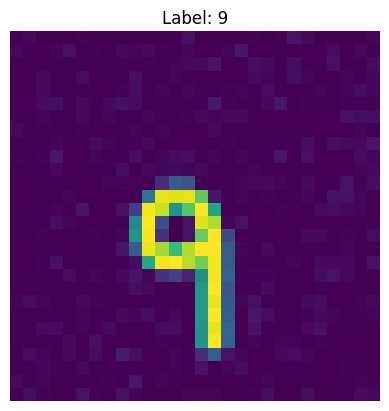

<bound method _EagerTensorBase.numpy of <tf.Tensor: shape=(28, 28, 1), dtype=float32, numpy=
array([[[0.        ],
        [0.01960784],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.00784314],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.03921569],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.00784314],
        [0.        ],
        [0.00784314],
        [0.0509804 ],
        [0.02352941],
        [0.        ],
        [0.00392157],
        [0.        ],
        [0.        ],
        [0.01176471]],

       [[0.01960784],
        [0.        ],
        [0.        ],
        [0.01176471],
        [0.03921569],
        [0.        ],
        [0.00784314],
        [0.        ],
        [0.01960784],
        [0.01176471],
        [0.02352941],
        [0.00784314],
        [0.        ],
   

In [51]:
import matplotlib.pyplot as plt
import numpy as np
test = synthetic_val
for images, labels in synthetic_val.take(1):
    image = images[0]
    label = labels[0]

    plt.imshow(image.numpy().squeeze())
    plt.title(f"Label: {label.numpy()}")
    plt.axis("off")
    plt.show()
print(image.numpy)

In [52]:
train_ds = original_train.concatenate(
    synthetic_train
)

val_ds = original_val.concatenate(
    synthetic_val
)

train_ds = train_ds.shuffle(10000)

In [53]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-4
)

model.compile(

    optimizer=optimizer,

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [54]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(

        monitor="val_loss",

        patience=3,

        restore_best_weights=True

    ),

    tf.keras.callbacks.ModelCheckpoint(

        "../models/digit_classifier_finetuned.keras",

        save_best_only=True

    )

]

In [55]:
print("Original train batches:", original_train.cardinality().numpy())
print("Synthetic train batches:", synthetic_train.cardinality().numpy())

Original train batches: 7000
Synthetic train batches: 3500


In [56]:
model.evaluate(synthetic_val)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.1723 - loss: 9.4271


[9.60244369506836, 0.16841666400432587]

In [57]:
history = model.fit(

    synthetic_train,

    validation_data=synthetic_val,

    epochs=10,

    callbacks=callbacks

)

Epoch 1/10
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 42s 11ms/step - accuracy: 0.2587 - loss: 3.6017 - val_accuracy: 0.6251 - val_loss: 1.1918
Epoch 2/10
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - accuracy: 0.6410 - loss: 1.1089 - val_accuracy: 0.8168 - val_loss: 0.5941
Epoch 3/10
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.7903 - loss: 0.6385 - val_accuracy: 0.8845 - val_loss: 0.3711
Epoch 4/10
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - accuracy: 0.8594 - loss: 0.4346 - val_accuracy: 0.9219 - val_loss: 0.2522
Epoch 5/10
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.8966 - loss: 0.3150 - val_accuracy: 0.9441 - val_loss: 0.1847
Epoch 6/10
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.9245 - loss: 0.2312 - val_accuracy: 0.9578 - val_loss: 0.1390
Epoch 7/10
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - accuracy: 0.9410 - loss: 0.1869 - val_accuracy: 0.9663 - val_loss: 0.1095
Epoch 8/10
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.9496 - 

In [58]:
model.save(
    "../models/digit_classifier_finetuned4.keras"
)